
**Завдання 1**: Завантажте дані `medical-charges.csv` в пандас датафрейм і виведіть перші 5 записів. Напишіть, як ви можете підійти до вирішення задачі прогнозування колонки `charges` на основі інших колонок виходячи з наявних на даний момент знань (без ML методів, чисто з використанням аналітики). Запишіть 3 або більше ідей, які приходять вам на думку нижче:

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
df = pd.read_csv("drive/MyDrive/Colab Notebooks/data/medical-charges.csv")

Mounted at /content/drive


In [2]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Зробити загальний статистичний звіт df.describe() для розуміння даних.  
Зробити стастичний звіт за групуванням, наприклад:
df.groupby(['smoker', 'sex'])['charges'].describe() та інші - подивитись на результати.  
Побудувати графік залежності age (а потім bmi) від charges.
Зробити висновок, що чим вище вік та індекс маси тіла то платят більше, курці платять більше, чоловікі курці платять більше ніж жінки курці.
1. Спробувати зробити таблицю з урахуванням віку (групи за виявленними квартилями) і, в залежності от того жінка/чоловік, курить/не курить, дивитися на медіану charges.
2. Створити правила, які допоможуть прогнозувати charges. Типу: якщо чоловік, до 30 років, курить і має bmi<26.3 то charges = 5тис.
3. Порахувати коєфіціенти відхилення по групам. І помножувати загальну медіану на ці коефіціенти в залежності від того чоловік/жінка, курить/не курить.

**Завдання 2**: Візуалізуйте розподіл медичних зборів (`charges`) у вигляді інтерактивної гістограми plotly з розбиттями за категоріями ознак
1. `sex`
2. `region`

Додайте маржинальний графік у вигляді бокс-плота вгорі по дикретним категоріям ознак.
Скористайтесь прикладом візуалізації з лекції.
Опишіть свої спостереження.

In [18]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline

In [19]:
fig = px.histogram(df,
                   x='charges',
                   marginal='box',
                   color='sex',
                   title='Розподіл медичних зборів')
fig.update_layout(bargap=0.1)
fig.show()

In [20]:
fig = px.histogram(df,
                   x='charges',
                   marginal='box',
                   color='region',
                   title='Розподіл медичних зборів')
fig.update_layout(bargap=0.1)
fig.show()

In [21]:
fig = px.histogram(df,
                   x='charges',
                   facet_col='region',
                   marginal='box',
                   color='sex',
                   title='Розподіл медичних зборів')
fig.update_layout(bargap=0.1)
fig.show()

Мінімум й медіана на Box Plot приблизно рівні незалежно від статі, але вже 75 персентиль і максімум значно відрізняються: чоловіки платят більше. Можливо серез чоловікі більше курців, або ж є інші фактори які впливають на виплати.  
По репіонам минімум та медіана не дуже відрізняються (1600 і 1200), а ось середне, 75 персентиль и максімум вже більше. Можливо, наприклад, у southeast несприятливі умови для здоровья (більше курців, не займаються спортом та мають зайву вагу). Також по регіонам підтверджується що чоловікі платят більше ніж жінки.

**Завдання 3**: Візуалізуйте з `plotly` розподіл кожного з настуних стовпців відносно того, чи є людина курцем (`smoker`)
- `region`
- `children`

та опишіть коротко свої спостереження.

In [24]:
px.histogram(df, x='smoker', color='region', title='Smoker')

In [27]:
px.histogram(df, x='smoker', color='children', title='Smoker')

In [28]:
px.histogram(df, x='smoker', color='children', barnorm='percent', title='Smoker')

Загалом видно що некурців значно більше, ніж курців.  
По регіонам курці/не курці розподілені рівномірно, тобто цей показник не залежить від регіону.  
По залежності чи бездітні курять частіше, ніж багатодітні - теж не бачу різниці, курять однаково.

**Завдання 4**: Візуалізуйте звʼязок між стовпцем `charges` та `children` використовуючи графіки-скрипки (`px.violin`). Опишіть свої спостереження.

In [29]:
fig = px.violin(
    df,
    x='children',
    y='charges',
    color='children',
    box=True,
    title='Звʼязок між медичними зборами та кількістю дітей'
)
fig.show()

In [30]:
df['children'].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


У груп від 0 до 3х дітей верхні хвостики скрипокйдуть дуже високо - до 60k-70k. Там більшість дорогих зборів.  
У груп, де 4 і 5 діток, графіки не такі витягнутіу. Високих зборів там практично немає.  
Але це може бути з-за того, що ми маємо невелику кількість даних по цим групам якщо порівнювати з попередніми групами.

**Завдання 5.** Розглянемо модель для користувачів, які не є курцями (`no_smoker_df`):

$$charges = w \times age + b$$

Спробуйте 3 різні пари параметрів `w` та `b` аби вручну підігнати лінію під дані використовуючи наведені допоміжні функції `estimate_charges` та `try_parameters`. Опишіть спостереження.
Пари параметрів мають бути НЕ такі, як були наведені в лекції.

In [32]:
non_smoker_df = df[df.smoker == 'no']

In [33]:
def estimate_charges(age, w, b):
    return w * age + b

In [34]:
def try_parameters(df, w, b):
    ages = df.age
    target = df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

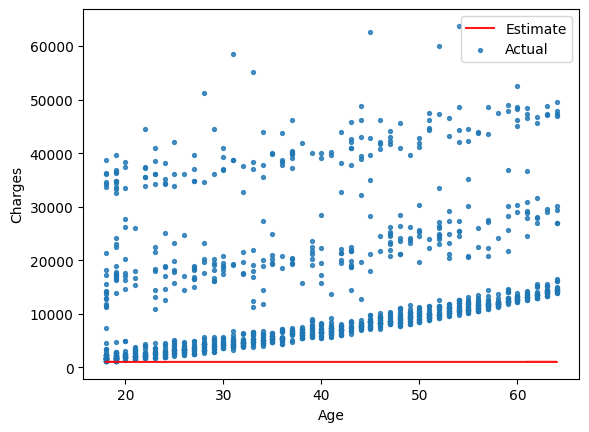

In [58]:
try_parameters(df, 0, 1000)

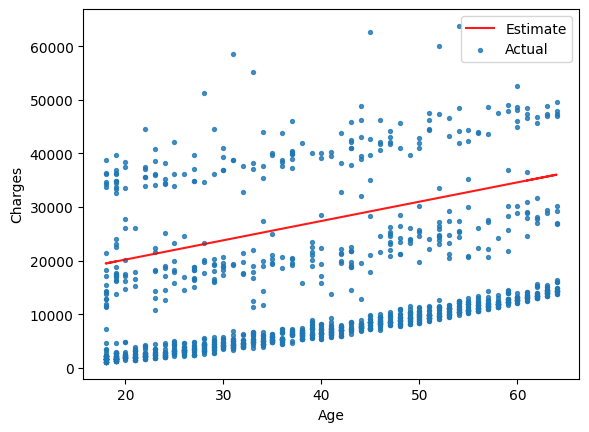

In [60]:
try_parameters(df, 360, 13000)

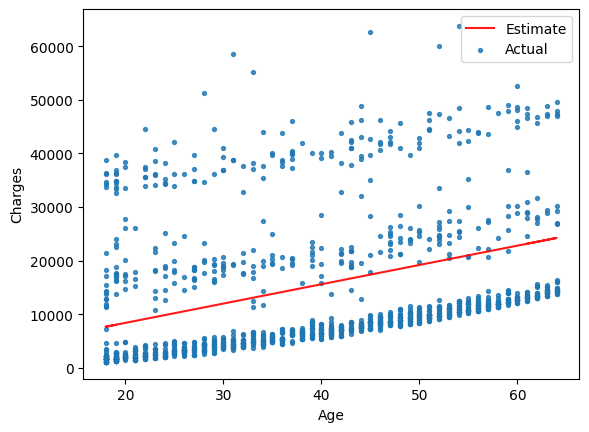

In [61]:
try_parameters(df, 360, 1200)

Однією линиєю неможливо охопити всі три групи точок на графіку. Якщо підлаштувати під нижню групу - там де найбільше скупчення - то не зможемо отримати великі виплати, а посередині - отримаємо великі помилки – для нижніх передбачення будуть завищені, для верхніх – занижені.  
Вирішила взяти b на рівні min виплат, а w підібрала як різницю між виплатами за 25% і min / на різницю між віком за 25% і min.
Можливо так загальна сума відхилень буде меншою.

**Завдання 6**: Напишіть фукнцію для обчислення root mean squared error згідно з формулою цієї метрики точності моделі з використанням `numpy`.

Обчисліть RMSE для тих пар пареметрів, які Ви спробували в завданні 5.

Яке найнижче значення втрат ви зможете досягти? Чи можете ви придумати загальну стратегію для знаходження кращих значень $w$ та $b$ методом проб та помилок?

In [68]:
import numpy as np
def rmse(targets, predicted):
    return np.sqrt(np.mean(np.square(targets - predicted)))

In [69]:
w, b = 0, 1000
targets = non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df.age, w, b)

rmse(targets, predicted)

np.float64(9547.774668878295)

In [71]:
w, b = 360, 13000
targets = non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df.age, w, b)
rmse(targets, predicted)

np.float64(19359.705236513582)

In [72]:
w, b = 360, 1200
targets = non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df.age, w, b)
rmse(targets, predicted)

np.float64(8465.759510382497)

В середньому кожний отриманний прогноз буде відрізнятися від факту на 8465 у.о.  
Можна спробувати далі підбирати w і b - трохи нижче w, вище b - можливо тоді помилка буде меньшою

In [77]:
w, b = 260, 2100

predicted = estimate_charges(non_smoker_df.age, w, b)
print("Нова помилка:", rmse(targets, predicted))

Нова помилка: 6083.221265183501


Загальна стратегія знаходження w та b методом проб та помилок можливо буде така:  
спочатку w = 0, а b = 1000 і рахуємо rmse поступово збільшуючі b. Знаходимо найменьшу помилку і фіксуємо b.  
Потім теж саме робимо з w, але b залишаємо ту, що знайшли на попередньому кроці.